# SI618 Project 3 Machine Learning


### Project Title: Predicting Bike-Sharing Demand: A Weather-Driven Analysis for Capital Bikeshare

Fall24 SI618 Group 17

School of Information, University of Michigan

### Team Members

- Yidan Chang (yidanydc)
- Zhuxin Wu (zhuxinwu)
- Shangqing Wei (weishq)


## Target Description

Our objective is to analyze and group bike-sharing stations based on their daily usage patterns，environmental conditions and geographic coordinates. By leveraging clustering techniques such as K-means and hierarchical clustering, we aim to uncover hidden patterns in how different stations are utilized across various conditions, including seasonal variations, demographic preferences, and weather factors like temperature, precipitation, and wind speed. This analysis will help us identify station-specific demand profiles and group stations with similar usage behaviors.

By incorporating user types (e.g., casual vs. registered users) and temporal dynamics (e.g., weekday vs. weekend usage), we can further understand how external factors influence demand at individual stations. For instance, some stations may exhibit high demand during peak commuting hours, while others may serve more recreational users during weekends.

The findings from this project will provide actionable insights for optimizing resource allocation, such as improving bike redistribution strategies and guiding infrastructure planning. By identifying clusters of stations with similar characteristics, city planners and bike-share operators can develop targeted strategies to improve service efficiency and enhance user satisfaction. Deliverables will include interactive visualizations, detailed usage profiles for each cluster, and a set of data-driven recommendations to address operational challenges.


## Data Preprocessing


### Data Loading


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


In [98]:
station_list = pd.read_csv("bikeshare/station_list.csv")
weather = pd.read_csv("bikeshare/weather.csv")
rent_detail = pd.read_csv("bikeshare/daily_rent_detail.csv")
usage_frequency = pd.read_csv("bikeshare/usage_frequency.csv")

/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_23774/1982516436.py:3: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  rent_detail = pd.read_csv("bikeshare/daily_rent_detail.csv")


### Data cleaning and handling of issues


#### Merging and Data Type Converting


In the third part of the project, we need to adjust the data instead of using the tables in the first two parts to some extent.

In the data merging step, our work is mainly focus on:

- Instead of merging the weather data with the usage_frequeny data, we choose to merge it with the rent_detail data this time. This makes sure that the data we perform machine learning has enough columns of features.
- To minimize the computational complexity associated with year, we confine all of the rent detail data to the same year, rather than across years. Our new time span is 2023.1.1 to 2023.12.31. We use the rent detail data and the weather data in this time scale.
- We also want to remove some unnecessary columns, such as station information and the text description in the weather table, etc. In order for subsequent machine learning models to process the data faster and reduce the amount of computation, we use stations' codes instead of their names. Therefore we will also drop the stations' names in rent_detail table.


In [99]:
rent_detail_23 = rent_detail[
    (rent_detail["started_at"] >= "2023-01-01 00:00:00")
    & (rent_detail["started_at"] <= "2023-12-31 23:59:59")
]
# rent_detail_23.to_csv('bikeshare/daily_rent_detail_2023.csv', index=False)

In [100]:
usage_frequency_23 = usage_frequency[
    (usage_frequency["date"] >= "2023-01-01")
    & (usage_frequency["date"] <= "2023-12-31")
]

In [101]:
usage_frequency_23.reset_index(drop=True, inplace=True)
usage_frequency_23[["pickup_counts", "dropoff_counts"]].astype("float64")
usage_frequency_23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219469 entries, 0 to 219468
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            219469 non-null  object 
 1   station_name    219469 non-null  object 
 2   pickup_counts   219469 non-null  int64  
 3   dropoff_counts  219469 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.7+ MB


In [102]:
rent_detail_23.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
7830706,65F0ACD101BF0D49,classic_bike,2023-01-04 19:34:07,2023-01-04 19:39:29,East Falls Church Metro / Sycamore St & 19th St N,31904.0,W Columbia St & N Washington St,32609.0,38.885321,-77.156427,38.885621,-77.166917,member
7830707,D75158CE73DC43F0,classic_bike,2023-01-27 15:26:38,2023-01-27 19:21:36,Carroll & Westmoreland Ave,32025.0,Fenton St & Ellsworth Dr,32036.0,38.975000,-77.011210,38.997033,-77.025608,member
7830708,33E85889625FF7CA,classic_bike,2023-01-05 20:44:38,2023-01-05 20:51:18,15th & L St NW,31276.0,Thomas Circle,31241.0,38.903649,-77.034918,38.905900,-77.032500,member
7830709,E1F055A1651F47A1,classic_bike,2023-01-03 17:45:14,2023-01-03 17:57:23,Hartland Rd & Harte Pl,32255.0,Merrifield Cinema & Merrifield Town Center,32235.0,38.878601,-77.222808,38.870093,-77.229970,member
7830710,88CC90CEEC298BAF,classic_bike,2023-01-03 05:18:46,2023-01-03 05:25:50,Merrifield Cinema & Merrifield Town Center,32235.0,Hartland Rd & Harte Pl,32255.0,38.870093,-77.229970,38.878601,-77.222808,member


In [103]:
rent_detail_23_day = rent_detail_23.copy()
rent_detail_23_day["started_day"] = pd.to_datetime(
    rent_detail_23_day["started_at"]
).dt.date
rent_detail_23_day.shape

(4467334, 14)

In [104]:
station_list

,station_id,station_name
0,30200,9th St & Pennsylvania Ave NW
1,30201,9th & G St NW
2,31000,Eads St & 15th St S
3,31001,18th St & S Eads St
4,31002,Crystal Dr & 20th St S
...,...,...
911,32901,6035 Warehouse
912,32902,Motivate Tech Office
913,32906,V1 Warehouse Test Station
914,32909,tech trailer V-1


In [105]:
station_list = station_list.drop_duplicates(subset="station_id")

In [106]:
rent_detail_station_geo = rent_detail_23_day[
    [
        "started_day",
        "start_station_id",
        "end_station_id",
        "start_lat",
        "start_lng",
        "end_lat",
        "end_lng",
    ]
].reset_index(drop=True)
rent_detail_station = pd.merge(
    rent_detail_station_geo,
    station_list,
    left_on="start_station_id",
    right_on="station_id",
    how="left",
)
rent_detail_station.head()

,started_day,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,station_id,station_name
0,2023-01-04,31904.0,32609.0,38.885321,-77.156427,38.885621,-77.166917,31904.0,East Falls Church Metro / Sycamore St & 19th St N
1,2023-01-27,32025.0,32036.0,38.975000,-77.011210,38.997033,-77.025608,32025.0,Carroll & Westmoreland Ave
2,2023-01-05,31276.0,31241.0,38.903649,-77.034918,38.905900,-77.032500,31276.0,15th & L St NW
3,2023-01-03,32255.0,32235.0,38.878601,-77.222808,38.870093,-77.229970,32255.0,Hartland Rd & Harte Pl
4,2023-01-03,32235.0,32255.0,38.870093,-77.229970,38.878601,-77.222808,32235.0,Merrifield Cinema & Merrifield Town Center


In [107]:
print(rent_detail_23.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4467334 entries, 7830706 to 12298039
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 477.2+ MB
None


In [108]:
# Get the mode for each start_station_id
station_coords = (
    rent_detail_station.groupby("start_station_id")[["start_lat", "start_lng"]]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)
station_coords.rename(
    columns={"start_lat": "unified_lat", "start_lng": "unified_lng"}, inplace=True
)

station_coords

,start_station_id,unified_lat,unified_lng
0,30200.0,38.894280,-77.023979
1,30201.0,38.898097,-77.023924
2,31000.0,38.858971,-77.053230
3,31002.0,38.856425,-77.049232
4,31003.0,38.861056,-77.049417
...,...,...,...
762,32607.0,38.879720,-77.178408
763,32608.0,38.885434,-77.173605
764,32609.0,38.885621,-77.166917
765,32901.0,38.963810,-77.010266


In [109]:
rent_detail_station = rent_detail_station.merge(
    station_coords, on="start_station_id", how="left"
)
rent_detail_station["start_lat"] = rent_detail_station["unified_lat"]
rent_detail_station["start_lng"] = rent_detail_station["unified_lng"]
rent_detail_station.drop(
    columns=["unified_lat", "unified_lng", "end_station_id", "end_lat", "end_lng"],
    inplace=True,
)
rent_detail_station = rent_detail_station.drop_duplicates()
rent_detail_station

,started_day,start_station_id,start_lat,start_lng,station_id,station_name
0,2023-01-04,31904.0,38.885321,-77.156427,31904.0,East Falls Church Metro / Sycamore St & 19th St N
1,2023-01-27,32025.0,38.975000,-77.011210,32025.0,Carroll & Westmoreland Ave
2,2023-01-05,31276.0,38.903649,-77.034918,31276.0,15th & L St NW
3,2023-01-03,32255.0,38.878601,-77.222808,32255.0,Hartland Rd & Harte Pl
4,2023-01-03,32235.0,38.870093,-77.229970,32235.0,Merrifield Cinema & Merrifield Town Center
...,...,...,...,...,...,...
4465127,2023-12-23,31065.0,38.880705,-77.085960,31065.0,N Pershing Dr & N Wayne St
4465576,2023-12-22,31316.0,38.946182,-77.080590,31316.0,Yuma St & Tenley Circle NW
4465895,2023-12-21,31521.0,38.932930,-76.979517,31521.0,18th & Monroe St NE
4466090,2023-12-01,32040.0,38.961150,-77.088659,32040.0,Friendship Blvd & Willard Ave


In [110]:
rent_detail_station.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219816 entries, 0 to 4466632
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   started_day       219816 non-null  object 
 1   start_station_id  219451 non-null  object 
 2   start_lat         219451 non-null  float64
 3   start_lng         219451 non-null  float64
 4   station_id        219451 non-null  float64
 5   station_name      219451 non-null  object 
dtypes: float64(3), object(3)
memory usage: 11.7+ MB


In [111]:
rent_detail_station.dropna(inplace=True)
rent_detail_station["started_day"] = pd.to_datetime(rent_detail_station["started_day"])
usage_frequency_23["date"] = pd.to_datetime(usage_frequency_23["date"])
rent_station_frequency = pd.merge(
    rent_detail_station,
    usage_frequency_23,
    left_on=["started_day", "station_name"],
    right_on=["date", "station_name"],
    how="left",
)
rent_station_frequency.dropna(inplace=True)
rent_station_frequency.drop(columns=["date", "station_name"], inplace=True)
rent_station_frequency["station_id"] = rent_station_frequency.station_id.astype(
    "int"
).astype("object")

/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_23774/3233639626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usage_frequency_23["date"] = pd.to_datetime(usage_frequency_23["date"])


<Axes: xlabel='started_day', ylabel='count'>

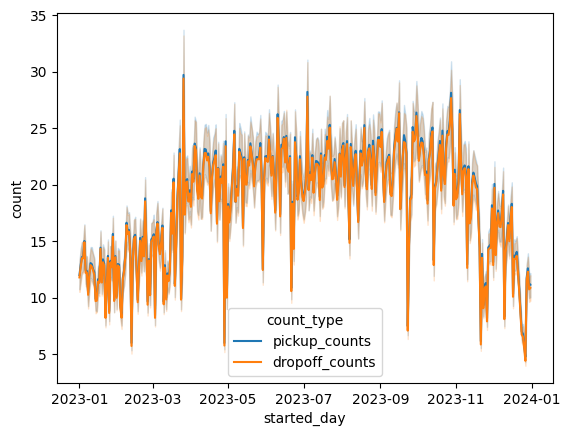

In [112]:
rent_station_frequency_melted = rent_station_frequency.melt(
    id_vars="started_day",
    value_vars=["pickup_counts", "dropoff_counts"],
    var_name="count_type",
    value_name="count",
)
sns.lineplot(
    data=rent_station_frequency_melted, x="started_day", y="count", hue="count_type"
)

In [113]:
rent_station_frequency

,started_day,start_station_id,start_lat,start_lng,station_id,pickup_counts,dropoff_counts
0,2023-01-04,31904.0,38.885321,-77.156427,31904,7.0,12.0
1,2023-01-27,32025.0,38.975000,-77.011210,32025,5.0,2.0
2,2023-01-05,31276.0,38.903649,-77.034918,31276,21.0,27.0
3,2023-01-03,32255.0,38.878601,-77.222808,32255,2.0,2.0
4,2023-01-03,32235.0,38.870093,-77.229970,32235,2.0,3.0
...,...,...,...,...,...,...,...
219446,2023-12-23,31065.0,38.880705,-77.085960,31065,1.0,1.0
219447,2023-12-22,31316.0,38.946182,-77.080590,31316,1.0,0.0
219448,2023-12-21,31521.0,38.932930,-76.979517,31521,1.0,1.0
219449,2023-12-01,32040.0,38.961150,-77.088659,32040,1.0,0.0


In [114]:
station_sums_with_geo = (
    rent_station_frequency.groupby(
        ["station_id", "start_station_id", "start_lat", "start_lng"]
    )[["pickup_counts", "dropoff_counts"]]
    .sum()
    .reset_index()
)

station_sums_with_geo.rename(
    columns={"pickup_counts": "total_pickups", "dropoff_counts": "total_dropoffs"},
    inplace=True,
)
station_sums_with_geo.drop(columns="start_station_id", inplace=True)

In [115]:
rent_detail_23.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
7830706,65F0ACD101BF0D49,classic_bike,2023-01-04 19:34:07,2023-01-04 19:39:29,East Falls Church Metro / Sycamore St & 19th St N,31904.0,W Columbia St & N Washington St,32609.0,38.885321,-77.156427,38.885621,-77.166917,member
7830707,D75158CE73DC43F0,classic_bike,2023-01-27 15:26:38,2023-01-27 19:21:36,Carroll & Westmoreland Ave,32025.0,Fenton St & Ellsworth Dr,32036.0,38.975000,-77.011210,38.997033,-77.025608,member
7830708,33E85889625FF7CA,classic_bike,2023-01-05 20:44:38,2023-01-05 20:51:18,15th & L St NW,31276.0,Thomas Circle,31241.0,38.903649,-77.034918,38.905900,-77.032500,member
7830709,E1F055A1651F47A1,classic_bike,2023-01-03 17:45:14,2023-01-03 17:57:23,Hartland Rd & Harte Pl,32255.0,Merrifield Cinema & Merrifield Town Center,32235.0,38.878601,-77.222808,38.870093,-77.229970,member
7830710,88CC90CEEC298BAF,classic_bike,2023-01-03 05:18:46,2023-01-03 05:25:50,Merrifield Cinema & Merrifield Town Center,32235.0,Hartland Rd & Harte Pl,32255.0,38.870093,-77.229970,38.878601,-77.222808,member


In [116]:
rent_detail_23 = rent_detail_23.drop(["start_station_name", "end_station_name"], axis=1)

In [117]:
rent_detail_23["started_at"] = pd.to_datetime(rent_detail_23["started_at"])
rent_detail_23["ended_at"] = pd.to_datetime(rent_detail_23["ended_at"])
rent_detail_23["start_station_id"] = pd.to_numeric(
    rent_detail_23["start_station_id"], errors="coerce"
).astype("Int64")
rent_detail_23["end_station_id"] = pd.to_numeric(
    rent_detail_23["end_station_id"], errors="coerce"
).astype("Int64")


In [118]:
weather_23 = weather[
    (weather["datetime"] >= "2023-01-01")
    & (weather["datetime"] <= "2023-12-31 23:59:59")
]

In [119]:
print(weather_23.info())

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 975 to 1339
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              365 non-null    object 
 1   datetime          365 non-null    object 
 2   tempmax           365 non-null    float64
 3   tempmin           365 non-null    float64
 4   temp              365 non-null    float64
 5   feelslikemax      365 non-null    float64
 6   feelslikemin      365 non-null    float64
 7   feelslike         365 non-null    float64
 8   dew               365 non-null    float64
 9   humidity          365 non-null    float64
 10  precip            365 non-null    float64
 11  precipprob        365 non-null    int64  
 12  precipcover       365 non-null    float64
 13  preciptype        179 non-null    object 
 14  snow              365 non-null    float64
 15  snowdepth         365 non-null    float64
 16  windgust          365 non-null    float64
 17 

In [120]:
weather_23.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
975,"Washington,DC,USA",2023-01-01,16.3,6.4,11.0,16.3,5.4,10.7,7.9,82.2,...,8.7,4,10.0,2023-01-01T07:26:52,2023-01-01T16:56:42,0.32,"Rain, Partially cloudy",Clearing in the afternoon with morning rain.,rain,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."
976,"Washington,DC,USA",2023-01-02,17.2,4.4,10.5,17.2,2.4,10.1,6.8,79.3,...,5.7,4,10.0,2023-01-02T07:26:59,2023-01-02T16:57:31,0.35,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."
977,"Washington,DC,USA",2023-01-03,20.0,10.1,15.2,20.0,10.1,15.2,11.3,78.5,...,3.4,2,10.0,2023-01-03T07:27:04,2023-01-03T16:58:22,0.39,Overcast,Cloudy skies throughout the day.,cloudy,"KDCA,72405013743,72403793728,KGAI,KADW,KDAA,AS..."
978,"Washington,DC,USA",2023-01-04,18.3,11.9,15.3,18.3,11.9,15.3,12.9,85.4,...,2.8,2,10.0,2023-01-04T07:27:07,2023-01-04T16:59:14,0.42,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KGAI,KADW,KDAA,AS..."
979,"Washington,DC,USA",2023-01-05,17.8,9.8,13.5,17.8,7.3,13.3,7.8,70.4,...,6.0,4,10.0,2023-01-05T07:27:08,2023-01-05T17:00:08,0.46,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."


In [121]:
weather_23.loc[:, "datetime"] = pd.to_datetime(weather_23["datetime"]).dt.date

weather_23.loc[:, "sunrise"] = pd.to_datetime(weather_23["sunrise"], errors="coerce")
weather_23.loc[:, "sunset"] = pd.to_datetime(weather_23["sunset"], errors="coerce")

weather_23 = weather_23.drop(["name", "conditions", "description", "stations"], axis=1)

In [122]:
weather_23.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 975 to 1339
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          365 non-null    object 
 1   tempmax           365 non-null    float64
 2   tempmin           365 non-null    float64
 3   temp              365 non-null    float64
 4   feelslikemax      365 non-null    float64
 5   feelslikemin      365 non-null    float64
 6   feelslike         365 non-null    float64
 7   dew               365 non-null    float64
 8   humidity          365 non-null    float64
 9   precip            365 non-null    float64
 10  precipprob        365 non-null    int64  
 11  precipcover       365 non-null    float64
 12  preciptype        179 non-null    object 
 13  snow              365 non-null    float64
 14  snowdepth         365 non-null    float64
 15  windgust          365 non-null    float64
 16  windspeed         365 non-null    float64
 17 

In [123]:
rent_detail_23["started_day"] = rent_detail_23["started_at"].dt.date

data = rent_detail_23.merge(
    weather_23, left_on="started_day", right_on="datetime", how="left"
)
data = data.drop(["started_day", "datetime"], axis=1)

In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4467334 entries, 0 to 4467333
Data columns (total 39 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ride_id           object        
 1   rideable_type     object        
 2   started_at        datetime64[ns]
 3   ended_at          datetime64[ns]
 4   start_station_id  Int64         
 5   end_station_id    Int64         
 6   start_lat         float64       
 7   start_lng         float64       
 8   end_lat           float64       
 9   end_lng           float64       
 10  member_casual     object        
 11  tempmax           float64       
 12  tempmin           float64       
 13  temp              float64       
 14  feelslikemax      float64       
 15  feelslikemin      float64       
 16  feelslike         float64       
 17  dew               float64       
 18  humidity          float64       
 19  precip            float64       
 20  precipprob        int64         
 21  precipco

In [125]:
data.head()

,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,...,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,icon
0,65F0ACD101BF0D49,classic_bike,2023-01-04 19:34:07,2023-01-04 19:39:29,31904,32609,38.885321,-77.156427,38.885621,-77.166917,...,85.1,15.9,32.2,2.8,2,10.0,2023-01-04 07:27:07,2023-01-04 16:59:14,0.42,partly-cloudy-day
1,D75158CE73DC43F0,classic_bike,2023-01-27 15:26:38,2023-01-27 19:21:36,32025,32036,38.975000,-77.011210,38.997033,-77.025608,...,46.9,16.0,107.9,9.4,5,10.0,2023-01-27 07:18:40,2023-01-27 17:23:33,0.20,partly-cloudy-day
2,33E85889625FF7CA,classic_bike,2023-01-05 20:44:38,2023-01-05 20:51:18,31276,31241,38.903649,-77.034918,38.905900,-77.032500,...,75.8,15.9,71.1,6.0,4,10.0,2023-01-05 07:27:08,2023-01-05 17:00:08,0.46,partly-cloudy-day
3,E1F055A1651F47A1,classic_bike,2023-01-03 17:45:14,2023-01-03 17:57:23,32255,32235,38.878601,-77.222808,38.870093,-77.229970,...,90.8,15.6,38.6,3.4,2,10.0,2023-01-03 07:27:04,2023-01-03 16:58:22,0.39,cloudy
4,88CC90CEEC298BAF,classic_bike,2023-01-03 05:18:46,2023-01-03 05:25:50,32235,32255,38.870093,-77.229970,38.878601,-77.222808,...,90.8,15.6,38.6,3.4,2,10.0,2023-01-03 07:27:04,2023-01-03 16:58:22,0.39,cloudy


In [126]:
data.isna().sum()

ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_id     406630
end_station_id       432484
start_lat                 0
start_lng                 0
end_lat                5945
end_lng                5945
member_casual             0
tempmax                   0
tempmin                   0
temp                      0
feelslikemax              0
feelslikemin              0
feelslike                 0
dew                       0
humidity                  0
precip                    0
precipprob                0
precipcover               0
preciptype          2475415
snow                      0
snowdepth                 0
windgust                  0
windspeed                 0
winddir                   0
sealevelpressure          0
cloudcover                0
visibility                0
solarradiation            0
solarenergy               0
uvindex                   0
severerisk                0
sunrise             

#### Null Values


- Since we want to cluster the start station of each rent record, we drop the data where the start station is null.
- For records with null end station information, we chose to retain them and fill these null values with their start station's code.
- For data that have null values in weather information, according to the original data description, we can find that all the dates with missing preciptype are not rainy, so we directly use "not rain" to fill in the null value.


In [127]:
data = data.dropna(subset="start_station_id")

In [128]:
data["end_station_id"] = data["end_station_id"].fillna(data["start_station_id"])
data["end_lat"] = data["end_lat"].fillna(data["start_lat"])
data["end_lng"] = data["end_lng"].fillna(data["start_lng"])

In [129]:
data["preciptype"] = data["preciptype"].fillna("Not Rain")

In [130]:
data.isna().sum()

ride_id             0
rideable_type       0
started_at          0
ended_at            0
start_station_id    0
end_station_id      0
start_lat           0
start_lng           0
end_lat             0
end_lng             0
member_casual       0
tempmax             0
tempmin             0
temp                0
feelslikemax        0
feelslikemin        0
feelslike           0
dew                 0
humidity            0
precip              0
precipprob          0
precipcover         0
preciptype          0
snow                0
snowdepth           0
windgust            0
windspeed           0
winddir             0
sealevelpressure    0
cloudcover          0
visibility          0
solarradiation      0
solarenergy         0
uvindex             0
severerisk          0
sunrise             0
sunset              0
moonphase           0
icon                0
dtype: int64

#### Outlier


It is possible that some of the outliers may be present in our data (even if we didn't fully account for them in our first assignment), so we need to address these possible issues. Potential problems in our data may include:

- The time of the dropoff is earlier than the time of the pickup. These data are considered to be incorrect. Here we want to jop them.
- Numeric value anomaly. This may include climate data anomalies such as excessive temperatures or precipitation values. It may also include latitude and longitude data or station id data anomalies. We are not sure if this problem exists in our data, so we may describe columns where the data type is numeric.
- We may have duplicate records in our data. If two records have the same ride_id, we consider them to be anomalous duplicates and need to be deleted.


In [131]:
invalid_count = (rent_detail_23["ended_at"] < rent_detail_23["started_at"]).sum()
print(f"Number of rows where ended_at < started_at: {invalid_count}")


Number of rows where ended_at < started_at: 615


In [132]:
data = data.loc[data["ended_at"] >= data["started_at"], :]

In [133]:
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
print(numeric_cols)

Index(['start_station_id', 'end_station_id', 'start_lat', 'start_lng',
       'end_lat', 'end_lng', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'moonphase'],
      dtype='object')


In [134]:
data[numeric_cols].describe()

,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,tempmax,tempmin,temp,feelslikemax,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,4060580.0,4060580.0,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,...,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06
mean,31373.864042,31375.416839,3.890296e+01,-7.703240e+01,3.890201e+01,-7.703205e+01,2.276410e+01,1.316809e+01,1.772133e+01,2.308624e+01,...,2.313072e+01,1.997372e+02,1.016313e+03,6.185697e+01,1.534168e+01,1.476480e+02,1.276161e+01,6.518676e+00,1.476582e+01,4.846858e-01
std,280.686356,282.867277,2.628016e-02,3.420685e-02,2.614504e-02,3.407513e-02,7.762391e+00,7.476432e+00,7.387763e+00,8.785323e+00,...,7.644239e+00,1.038572e+02,6.770336e+00,2.344634e+01,1.586682e+00,5.936925e+01,5.126304e+00,2.292517e+00,1.212265e+01,2.889629e-01
min,30200.0,30200.0,3.878255e+01,-7.738259e+01,3.870000e+01,-7.752000e+01,-1.000000e-01,-8.400000e+00,-4.200000e+00,-5.000000e+00,...,9.100000e+00,3.000000e-01,9.958000e+02,1.000000e+00,4.800000e+00,8.400000e+00,7.000000e-01,0.000000e+00,1.000000e+01,0.000000e+00
25%,31210.0,31213.0,3.889054e+01,-7.704459e+01,3.889050e+01,-7.704460e+01,1.660000e+01,7.000000e+00,1.190000e+01,1.660000e+01,...,1.760000e+01,1.227000e+02,1.011300e+03,4.660000e+01,1.550000e+01,1.045000e+02,9.000000e+00,5.000000e+00,1.000000e+01,2.300000e-01
50%,31281.0,31281.0,3.890276e+01,-7.703169e+01,3.890227e+01,-7.703023e+01,2.430000e+01,1.410000e+01,1.900000e+01,2.430000e+01,...,2.160000e+01,1.962000e+02,1.015900e+03,6.500000e+01,1.600000e+01,1.520000e+02,1.320000e+01,7.000000e+00,1.000000e+01,5.000000e-01
75%,31609.0,31611.0,3.891360e+01,-7.701367e+01,3.891264e+01,-7.701246e+01,2.930000e+01,1.970000e+01,2.400000e+01,2.920000e+01,...,2.600000e+01,3.033000e+02,1.021100e+03,8.010000e+01,1.600000e+01,2.003000e+02,1.730000e+01,8.000000e+00,1.000000e+01,7.500000e-01
max,33200.0,33200.0,3.912586e+01,-7.682554e+01,3.917000e+01,-7.682554e+01,3.650000e+01,2.590000e+01,3.000000e+01,4.210000e+01,...,5.810000e+01,3.574000e+02,1.038600e+03,1.000000e+02,1.600000e+01,2.625000e+02,2.270000e+01,1.000000e+01,6.000000e+01,9.800000e-01


We can notice that there are no outliers in our numeric data and we don't need to remove some records.


In [135]:
data = data.drop_duplicates(subset=["ride_id"])

#### Group By Station and Datetime


Our goal is to cluster the station data, so we perform a groupby operation on each station's records in this step. It should be noted that we choose the start station for this task and we also split the start time into month and day in this step.

When doing group by, we follow these ideas for some columns:

- For the ride-related categorical data (rideable_type and member_casual), we count the number of occurrences of each category in all records at each station each day.
- For ride time, ride distance, and all weather-related numeric data, we record their average values as the corresponding attributes for the day of the station.
- Some of the categorical columns in the weather data are not treated specifically as they do not change in the same day.


In [136]:
data["month"] = data["started_at"].dt.month

data["day"] = data["started_at"].dt.day

data["ride_duration"] = (
    (data["ended_at"] - data["started_at"]).dt.total_seconds().astype(int)
)

data["ride_distance"] = (
    (data["end_lat"] - data["start_lat"]) ** 2
    + (data["end_lng"] - data["start_lng"]) ** 2
) ** 0.5

In [137]:
data.drop(
    ["started_at", "ended_at", "end_station_id", "end_lat", "end_lng"],
    axis=1,
    inplace=True,
)

In [138]:
grouped_data = (
    data.groupby(["month", "day", "start_station_id"])
    .agg(
        ride_count=("ride_id", "count"),
        start_lat=("start_lat", "mean"),
        start_lng=("start_lng", "mean"),
        classic_bike=("rideable_type", lambda x: (x == "classic_bike").sum()),
        docked_bike=("rideable_type", lambda x: (x == "docked_bike").sum()),
        electric_bike=("rideable_type", lambda x: (x == "electric_bike").sum()),
        avg_distance=("ride_distance", "mean"),
        avg_duration=("ride_duration", "mean"),
        casual_count=("member_casual", lambda x: (x == "casual").sum()),
        member_count=("member_casual", lambda x: (x == "member").sum()),
        tempmax=("tempmax", "mean"),
        tempmin=("tempmin", "mean"),
        temp=("temp", "mean"),
        feelslikemax=("feelslikemax", "mean"),
        feelslikemin=("feelslikemin", "mean"),
        feelslike=("feelslike", "mean"),
        dew=("dew", "mean"),
        humidity=("humidity", "mean"),
        precip=("precip", "mean"),
        precipprob=("precipprob", "mean"),
        precipcover=("precipcover", "mean"),
        preciptype=("preciptype", lambda x: x.mode().iat[0]),
        snow=("snow", "mean"),
        snowdepth=("snowdepth", "mean"),
        windgust=("windgust", "mean"),
        windspeed=("windspeed", "mean"),
        winddir=("winddir", "mean"),
        sealevelpressure=("sealevelpressure", "mean"),
        cloudcover=("cloudcover", "mean"),
        visibility=("visibility", "mean"),
        solarradiation=("solarradiation", "mean"),
        solarenergy=("solarenergy", "mean"),
        uvindex=("uvindex", "mean"),
        severerisk=("severerisk", "mean"),
        sunrise=("sunrise", "mean"),
        sunset=("sunset", "mean"),
        moonphase=("moonphase", "mean"),
        icon=("icon", lambda x: x.mode().iat[0]),
    )
    .reset_index()
)

In [139]:
grouped_data_copy = grouped_data.copy()

In [140]:
grouped_data["sunrise"] = pd.to_datetime(grouped_data["sunrise"], errors="coerce")
grouped_data["sunset"] = pd.to_datetime(grouped_data["sunset"], errors="coerce")

In [141]:
grouped_data.head()

,month,day,start_station_id,ride_count,start_lat,start_lng,classic_bike,docked_bike,electric_bike,avg_distance,...,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,icon
0,1,1,31000,6,38.858971,-77.053230,6,0,0,0.019847,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
1,1,1,31002,6,38.856425,-77.049232,6,0,0,0.016549,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
2,1,1,31003,7,38.861056,-77.049417,4,3,0,0.005941,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000256,0.32,rain
3,1,1,31004,2,38.857866,-77.059490,2,0,0,0.016923,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
4,1,1,31005,5,38.862303,-77.059936,3,2,0,0.021915,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain


In [142]:
grouped_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219449 entries, 0 to 219448
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   month             219449 non-null  int32         
 1   day               219449 non-null  int32         
 2   start_station_id  219449 non-null  Int64         
 3   ride_count        219449 non-null  int64         
 4   start_lat         219449 non-null  float64       
 5   start_lng         219449 non-null  float64       
 6   classic_bike      219449 non-null  int64         
 7   docked_bike       219449 non-null  int64         
 8   electric_bike     219449 non-null  int64         
 9   avg_distance      219449 non-null  float64       
 10  avg_duration      219449 non-null  float64       
 11  casual_count      219449 non-null  int64         
 12  member_count      219449 non-null  int64         
 13  tempmax           219449 non-null  float64       
 14  temp

In [143]:
# grouped_data.to_csv('bikeshare/grouped_data.csv', index=False)

In [144]:
rent_detail.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29,2020-05-31 18:25:22,Anacostia Library,31804,11th & H St NE,31614.0,38.865784,-76.978400,38.899983,-76.991383,casual
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04,2020-05-09 15:06:33,10th & E St NW,31256,21st St & Constitution Ave NW,31261.0,38.895914,-77.026064,38.892459,-77.046567,member
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19,2020-05-24 17:43:51,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268.0,38.934267,-77.057979,38.916787,-77.028139,member
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52,2020-05-27 15:47:13,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119.0,38.934267,-77.057979,38.921074,-77.031887,casual
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03,2020-05-31 14:30:30,Georgia Ave & Morton St NW,31419,17th & K St NW,31213.0,38.932128,-77.023500,38.902760,-77.038630,casual


This process ensures a consistent latitude and longitude for each station, removing duplicates and ambiguities.


**Justification**: Missing values can distort clustering outcomes by introducing noise or bias in the dataset. Imputation techniques, such as mean or median replacement, preserve dataset integrity while maintaining a balance of variability.

**Impact**: Reduces noise and ensures all records contribute to the clustering algorithm, leading to more reliable cluster formation.


### Feature scaling and normalization


In our analysis, we separate start_station_id and its attributes (start_lat, start_lng) into y, while keeping other features (e.g., weather features, ride time, etc.) in X.


In [145]:
X = grouped_data.drop(["start_station_id", "start_lat", "start_lng"], axis=1)
y = grouped_data[["start_station_id", "start_lat", "start_lng"]]

In [146]:
num_cols = X.select_dtypes(include=["float64", "int64", "int32"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
time_col = X.select_dtypes(include=["datetime64[ns]"]).columns
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print("time_col:", time_col)

num_cols: Index(['month', 'day', 'ride_count', 'classic_bike', 'docked_bike',
       'electric_bike', 'avg_distance', 'avg_duration', 'casual_count',
       'member_count', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'moonphase'],
      dtype='object')
cat_cols: Index(['preciptype', 'icon'], dtype='object')
time_col: Index(['sunrise', 'sunset'], dtype='object')


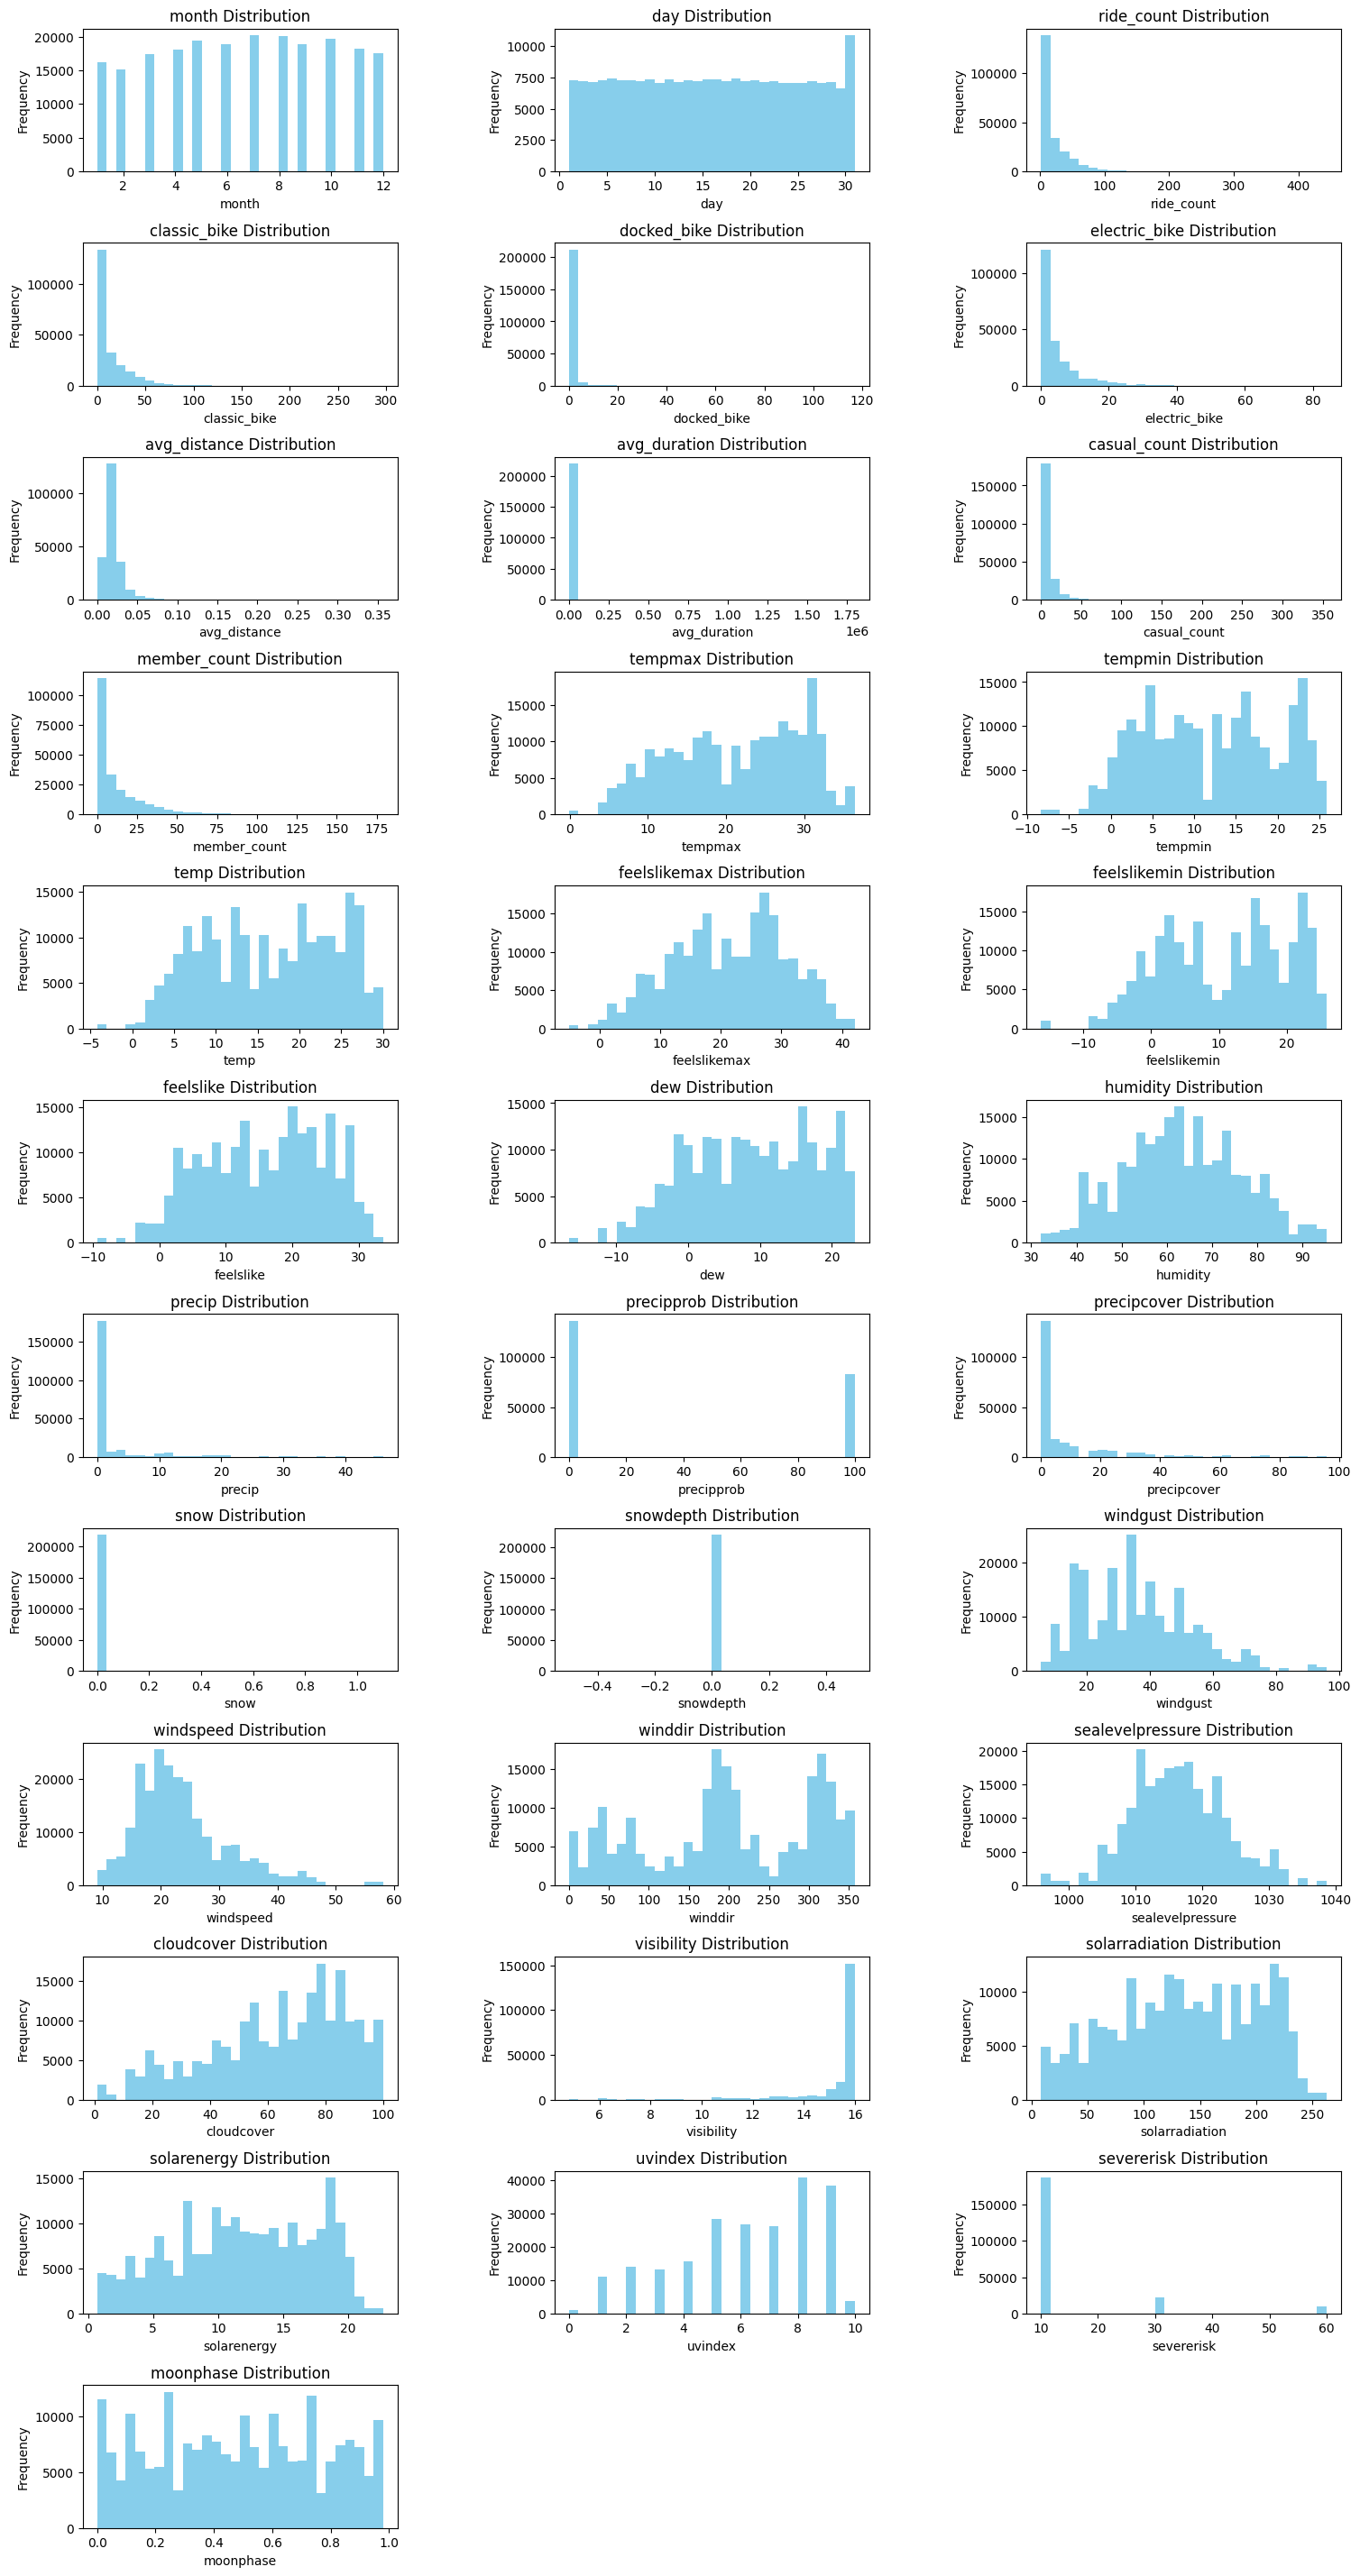

In [147]:
fig, axes = plt.subplots(
    len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(18, 36), dpi=100
)
fig.subplots_adjust(hspace=0.5, wspace=0.5)


for i, ax in enumerate(axes.flatten()):
    if i < len(num_cols):
        ax.hist(X[num_cols[i]], bins=30, color="skyblue")
        ax.set_title(f"{num_cols[i]} Distribution")
        ax.set_xlabel(f"{num_cols[i]}")
        ax.set_ylabel("Frequency")
    else:
        ax.axis("off")

plt.show()

We transformed the data mainly based on the following ideas:

- Numeric Data: Our numeric data are not always normally distributed. If we use standard scale for all of them, it doesn't make sense for some columns. Therefore, we selectively perform operations such as standardization and normalization on some columns, mainly based on their distribution characteristics.
- Time Data: For time related attributes, we convert them to relative time, or extract cyclical characteristics, depending on their specific content.
- Categorical Data: We use One-Hot Encoding and converts categorical variables (e.g. preciptype, icon) to 0/1 encoding.


In [148]:
log_transformer = FunctionTransformer(np.log1p, validate=True)


def compute_day_length(X):
    if not {"sunrise", "sunset"}.issubset(X.columns):
        raise ValueError("Input DataFrame must contain 'sunrise' and 'sunset' columns.")
    return (X["sunset"] - X["sunrise"]).dt.total_seconds().to_numpy().reshape(
        -1, 1
    ) / 3600


day_length_transformer = FunctionTransformer(compute_day_length, validate=False)


def cyclical_transform(X):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    sin = np.sin(2 * np.pi * X)
    cos = np.cos(2 * np.pi * X)
    return np.hstack((sin, cos))


cyclical_transformer = FunctionTransformer(cyclical_transform, validate=True)

numeric_normal = [
    "tempmax",
    "tempmin",
    "temp",
    "feelslikemax",
    "feelslikemin",
    "feelslike",
    "dew",
    "humidity",
    "windgust",
    "windspeed",
    "winddir",
    "sealevelpressure",
    "cloudcover",
    "solarradiation",
    "solarenergy",
    "uvindex",
]
numeric_skewed = [
    "ride_count",
    "classic_bike",
    "docked_bike",
    "electric_bike",
    "avg_distance",
    "avg_duration",
    "casual_count",
    "member_count",
    "precip",
    "precipprob",
    "precipcover",
    "snow",
    "snowdepth",
    "visibility",
    "severerisk",
]
numeric_cyclical = ["month", "day", "moonphase"]

time_columns = ["sunrise", "sunset"]

categorical_cols = ["preciptype", "icon"]


preprocessor = ColumnTransformer(
    transformers=[
        ("normal", StandardScaler(), numeric_normal),
        (
            "skewed",
            Pipeline(
                [
                    ("log", FunctionTransformer(np.log1p, validate=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            numeric_skewed,
        ),
        ("cyclical", cyclical_transformer, numeric_cyclical),
        ("day_length", day_length_transformer, time_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

transformed_X = pipeline.fit_transform(X)


In [149]:
transformed_X.shape

(219449, 49)

Add some features that can indicate the demand of each station in station_sums_with_geo dataframe that we preprocessed.


In [150]:
station_sums_with_geo["utilization_rate"] = (
    station_sums_with_geo["total_pickups"] + station_sums_with_geo["total_dropoffs"]
)
station_sums_with_geo["imbalance"] = (
    station_sums_with_geo["total_pickups"] - station_sums_with_geo["total_dropoffs"]
)
station_sums_with_geo["popularity_rank"] = (
    station_sums_with_geo["utilization_rate"].rank(ascending=False).astype("int")
)


In this step, we create a new feature about geographical distance to a key point.

We set the coordinate of white house as the key location because it is nearly the center af Washinton D.C.


In [151]:
from geopy.distance import geodesic

# White House coordinates
white_house_coords = (38.8977, -77.0365)

station_sums_with_geo["distance_to_white_house"] = station_sums_with_geo.apply(
    lambda row: geodesic(
        (row["start_lat"], row["start_lng"]), white_house_coords
    ).kilometers,
    axis=1,
)
station_sums_with_geo

,station_id,start_lat,start_lng,total_pickups,total_dropoffs,utilization_rate,imbalance,popularity_rank,distance_to_white_house
0,30200,38.894280,-77.023979,10129.0,13293.0,23422.0,-3164.0,123,1.150675
1,30201,38.898097,-77.023924,10987.0,12099.0,23086.0,-1112.0,129,1.091867
2,31000,38.858971,-77.053230,4087.0,4080.0,8167.0,7.0,268,4.537910
3,31002,38.856425,-77.049232,4596.0,4612.0,9208.0,-16.0,252,4.713385
4,31003,38.861056,-77.049417,4932.0,5088.0,10020.0,-156.0,240,4.219557
...,...,...,...,...,...,...,...,...,...
733,32607,38.879720,-77.178408,728.0,719.0,1447.0,9.0,483,12.472958
734,32608,38.885434,-77.173605,682.0,641.0,1323.0,41.0,495,11.972705
735,32609,38.885621,-77.166917,671.0,617.0,1288.0,54.0,500,11.393944
736,32901,38.963810,-77.010266,133.0,109.0,242.0,24.0,672,7.683596


In [152]:
station_sums_with_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   station_id               738 non-null    int64  
 1   start_lat                738 non-null    float64
 2   start_lng                738 non-null    float64
 3   total_pickups            738 non-null    float64
 4   total_dropoffs           738 non-null    float64
 5   utilization_rate         738 non-null    float64
 6   imbalance                738 non-null    float64
 7   popularity_rank          738 non-null    int64  
 8   distance_to_white_house  738 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 52.0 KB


**Justification**:
Normalization: Converts data into a common scale (e.g., between 0 and 1), especially useful when features have different units or ranges. It enhances the interpretability and ensures that distance calculations are consistent.

**Impact**:
Improves clustering performance by balancing the influence of all features.
Reduces computation complexity and ensures meaningful distance measurements for clusters.


### Dimensionality reduction


We choose PCA to reduce the dimensionality of the data while retaining the majority of the variance.

At first we made a heatmap to see the correlation in our transformed data.


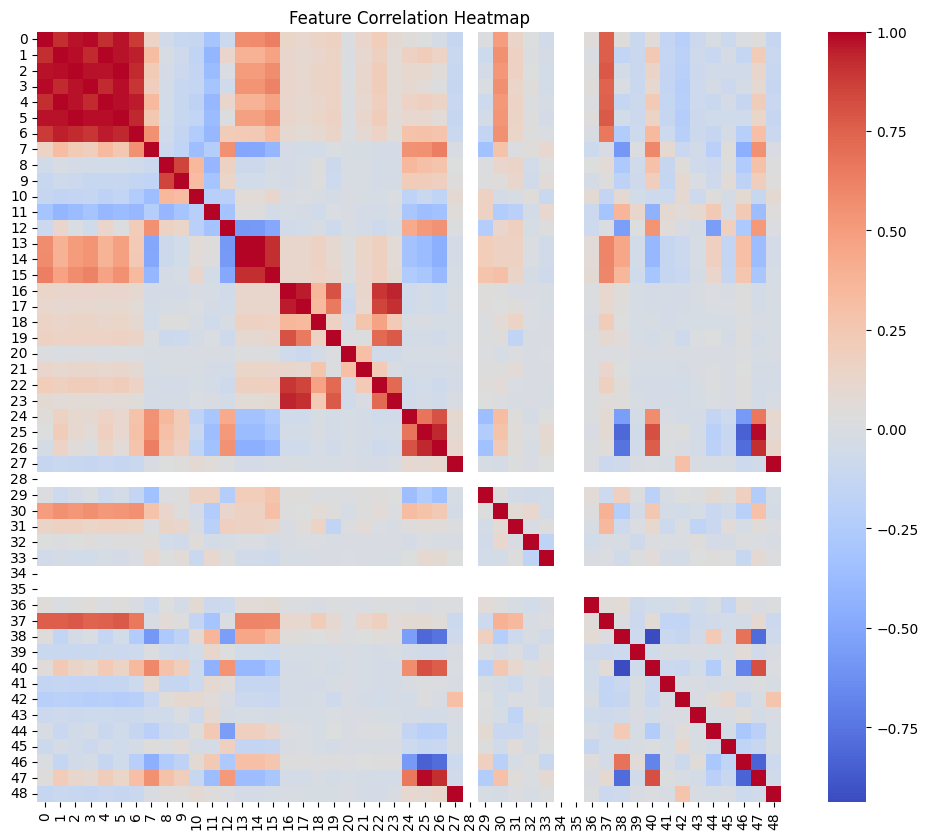

In [153]:
transformed_df = pd.DataFrame(transformed_X)
correlation_matrix = transformed_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In the correlation heatmap, there is a strong positive or negative correlation between some of the features, while the majority of the features have a weak correlation (close to 0, lighter color). This indicates that there are redundant features in the data, and the model can be optimized through feature selection or dimensionality reduction.


In [154]:
pca = PCA(n_components=8)
pca_X = pca.fit_transform(transformed_X)

print("Explained variance ratio:", pca.explained_variance_ratio_.sum())
print("Reduced data shape after PCA:", pca_X.shape)


Explained variance ratio: 0.8034199433873488
Reduced data shape after PCA: (219449, 8)


We select 8 components and these components can explain 80% of the information, which seems enough for our analysis. This can balance computational efficiency with the preservation of information, aligning well with clustering or other unsupervised learning techniques planned for subsequent analysis.


**Justification**: High-dimensional datasets can lead to the "curse of dimensionality," where distance metrics become less meaningful. Techniques like PCA is used to reduce dimensionality while retaining variance.

**Impact**: Simplifies data representation, making clusters more distinguishable and computationally efficient to process.


## Clustering Analysis


### KMeans


We chose clustering, specifically MiniBatch KMeans, as our primary approach to group daily bike station usage patterns into meaningful clusters based on ride behavior and environmental factors. With a dataset of 219,449 samples, standard KMeans can be computationally expensive, so we opted for MiniBatch KMeans due to its efficiency with large datasets. This method processes small random batches of data at a time, significantly reducing runtime while still delivering reliable results.


In [155]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


batch_sizes = [100, 300, 500, 700, 1000]
k_values = range(2, 11)


results = []

for batch_size in batch_sizes:
    for k in k_values:
        mb_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, random_state=42)
        cluster_labels = mb_kmeans.fit_predict(pca_X)
        
        inertia = mb_kmeans.inertia_
        sil_score = silhouette_score(pca_X, cluster_labels, sample_size=21000)  # subset for silhouette score computation: 10% of the data
        
        results.append({
            'batch_size': batch_size,
            'k': k,
            'inertia': inertia,
            'silhouette_score': sil_score,
        })
        


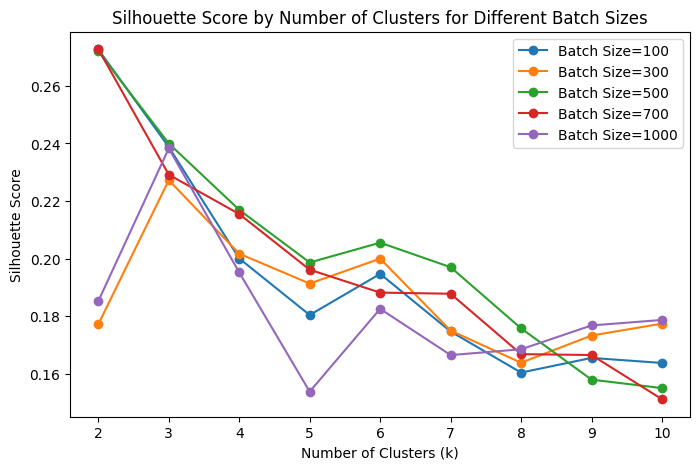

In [156]:
import pandas as pd
df_results = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
for batch_size in batch_sizes:
    subset = df_results[df_results['batch_size'] == batch_size]
    plt.plot(subset['k'], subset['silhouette_score'], marker='o', label=f'Batch Size={batch_size}')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters for Different Batch Sizes')
plt.legend()
plt.show()

In most cases, k=3 provides a high silhouette score and balances simplicity with meaningful clusters. While k=2 sometimes scores slightly higher, it oversimplifies the data. After k=3, the scores drop consistently, showing that adding more clusters doesn't improve the results. k=3 works well across all batch sizes, making it the best choice.

The batch size of 500 offers a good balance between clustering quality and computational efficiency.

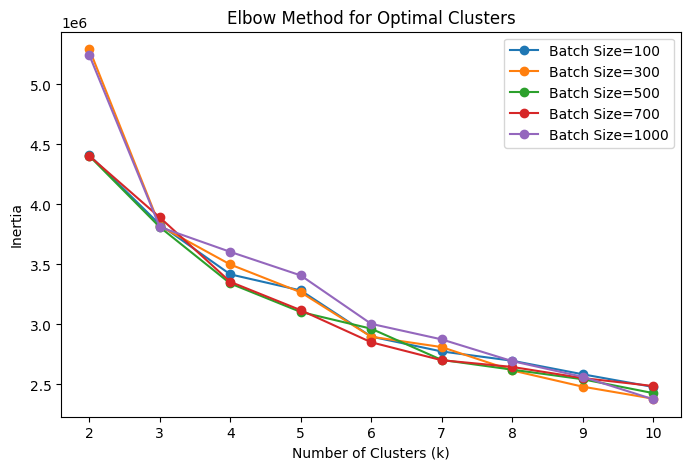

In [157]:
plt.figure(figsize=(8, 5))
for batch_size in batch_sizes:
    subset = df_results[df_results['batch_size'] == batch_size]
    plt.plot(subset['k'], subset['inertia'], marker='o', label=f'Batch Size={batch_size}')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.legend()
plt.show()


The inertia decreases as k increases, but the rate of decrease slows significantly after k=3, forming an "elbow" in the curve. So according to the elbow method, k=3 is also the optimal number of clusters.


In [158]:
optimal_k = 3
final_mb_kmeans = MiniBatchKMeans(
    n_clusters=optimal_k, batch_size=500, random_state=42
)
final_labels = final_mb_kmeans.fit_predict(pca_X)

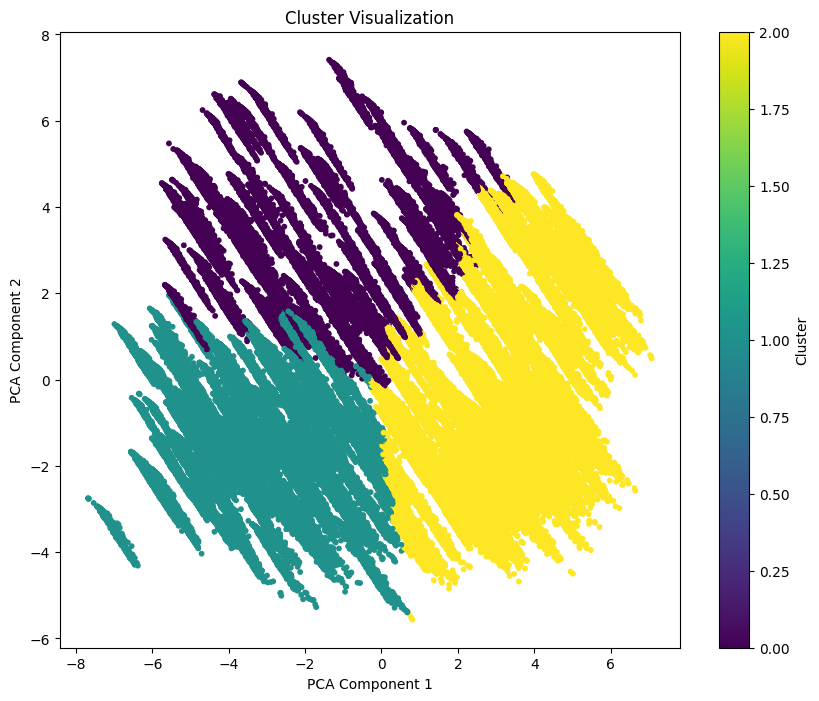

In [159]:
# Visualize Clustering Results
plt.figure(figsize=(10, 8))
plt.scatter(pca_X[:, 0], pca_X[:, 1], c=final_labels, cmap="viridis", s=10)
plt.title("Cluster Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

We computed summary statistics for each cluster.


In [160]:
grouped_data["Cluster"] = final_labels
numeric_cols = grouped_data.select_dtypes(include=["number"]).columns

cluster_summary = grouped_data.groupby("Cluster")[numeric_cols].mean()
print(cluster_summary)
cluster_counts = grouped_data["Cluster"].value_counts()


            month        day  start_station_id  ride_count  start_lat  \
Cluster                                                                 
0        6.254335  17.798313       31530.21333   13.757196  38.904245   
1        6.630827  15.101845      31539.627135   15.860866  38.904480   
2        6.838240  15.152864      31561.966843   22.512224  38.905802   

         start_lng  classic_bike  docked_bike  electric_bike  avg_distance  \
Cluster                                                                      
0       -77.051195     10.042163     0.233766       3.481267      0.019753   
1       -77.052732     11.478306     0.295675       4.086885      0.020052   
2       -77.055616     16.400209     0.802085       5.309930      0.020315   

         ...     winddir  sealevelpressure  cloudcover  visibility  \
Cluster  ...                                                         
0        ...  161.536408       1013.004728   86.736426   14.087407   
1        ...  244.220674       10

In [161]:
grouped_data["Cluster"] = final_labels

for col in categorical_cols:
    print(f"Distribution of {col} by Cluster:")
    print(grouped_data.groupby("Cluster")[col].value_counts(normalize=True))
    print("\n")

Distribution of preciptype by Cluster:
Cluster  preciptype       
0        rain                 0.976225
         rain,freezingrain    0.012422
         rain,snow            0.011353
1        Not Rain             0.761852
         rain                 0.155269
         rain,snow            0.036045
         rain,freezingrain    0.023697
         freezingrain         0.015438
         snow                 0.007699
2        Not Rain             0.575056
         rain                 0.424944
Name: proportion, dtype: float64


Distribution of icon by Cluster:
Cluster  icon             
0        rain                 0.919191
         cloudy               0.041940
         partly-cloudy-day    0.026113
         snow                 0.012756
1        partly-cloudy-day    0.798362
         clear-day            0.105742
         rain                 0.067564
         cloudy               0.021181
         snow                 0.007152
2        partly-cloudy-day    0.575747
         rain       

In [162]:
print("Cluster sizes:")
print(cluster_counts)

Cluster sizes:
Cluster
2    101397
1     73131
0     44921
Name: count, dtype: int64


## KMeans Results

**Cluster 0: Low Ride Counts & Rainy Weather Conditions**

- Ride Counts: This cluster experiences the lowest daily ride counts (13.76 average rides per day).
- Weather Conditions: Predominantly rainy, with 97.6% of trips occurring during rain. It also has the highest - cloud cover (86.7%) and lowest visibility (14.08 miles).
- Bike Usage: Classic bikes dominate, while electric bikes are used moderately (3.48%).
- Solar Radiation: The lowest among all clusters (60.34), corresponding to overcast or rainy conditions.


**Cluster 1: Balanced Bike Usage with Good Visibility**

- Ride Counts: Moderate daily ride counts, averaging 15.86 rides per day.
- Weather Conditions: 76.2% of trips occurred during non-rainy conditions, with partly-cloudy weather dominating.
- Bike Usage: Electric bikes are more popular here, averaging 4.09 trips per day, along with higher docked bike usage.
- Solar Radiation: Moderate solar radiation, indicating better weather conditions than Cluster 0.

**Cluster 2: High Ride Counts & Favorable Weather**

- Ride Counts: The highest daily ride counts (22.51 rides per day), driven by good weather conditions.
- Weather Conditions: The clearest among all clusters, with 57.5% of trips during non-rainy periods and significant clear-day (23.8%) trips.
- Bike Usage: Electric bikes dominate with the highest usage (5.31 trips per day), reflecting the popularity of these bikes in favorable conditions.
- Solar Radiation: The highest radiation and energy levels (180.59 and 15.61), indicating sunny periods with minimal cloud cover.



**Insights from KMeans**
- Weather Influence: Weather strongly impacts bike usage. Rainy and overcast conditions in Cluster 0 significantly reduce activity, while sunnier conditions in Cluster 2 drive higher usage, especially with electric bikes.
- Bike Preferences: Electric bikes are the most popular during favorable weather conditions in Cluster 2, while adverse weather in Cluster 0 sees more reliance on classic bikes.
- Seasonal and Temporal Trends: Clusters highlight seasonal and daily weather variations, showing how these factors shape station activity and influence user behavior.

**Cluster-Based Strategy Recommendations**
- Cluster 0 (Rainy Weather): Implement weather-specific strategies such as providing covered docking stations or offering ride promotions to boost ridership during rainy periods.
- Cluster 1 (Balanced Conditions): Focus on optimizing bike type availability to meet the moderate demand, ensuring a balanced supply of electric and classic bikes.
- Cluster 2 (Favorable Weather): Increase electric bike availability to match the high demand during sunny days. Consider expanding capacity at popular stations to accommodate peak usage.







### Agglomerative Clustering


To complement MiniBatch KMeans, we also applied Agglomerative Clustering to analyze the dataset from a hierarchical perspective.


In [163]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

sample_size = 21000  # 10% of 210,000
indices = np.random.choice(len(pca_X), sample_size, replace=False)
pca_sample = pca_X[indices]

In [164]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 3
linkage_method = "ward"

agg_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
agg_labels_sample = agg_model.fit_predict(pca_sample)

sil_score = silhouette_score(pca_sample, agg_labels_sample)

print(f"Silhouette Score for Agglomerative Clustering on Subsample: {sil_score:.4f}")


Silhouette Score for Agglomerative Clustering on Subsample: 0.2098


In [165]:
from sklearn.neighbors import KNeighborsClassifier

# Train a KNN classifier on the sample
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(pca_sample, agg_labels_sample)
agg_labels_full = knn.predict(pca_X)


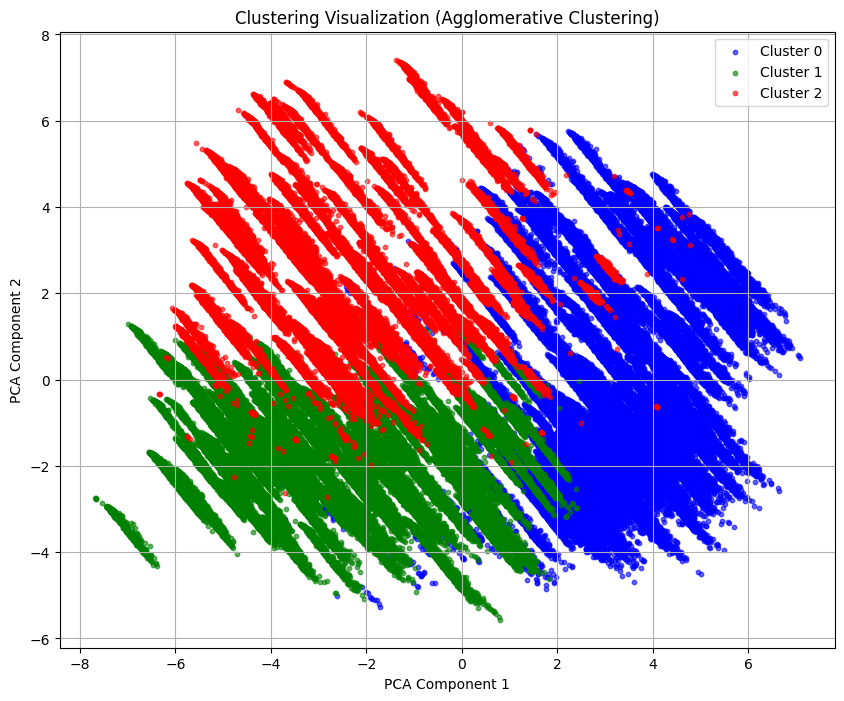

In [166]:
import matplotlib.pyplot as plt


cluster_colors = ["blue", "green", "red"]
cluster_labels = ["Cluster 0", "Cluster 1", "Cluster 2"]


plt.figure(figsize=(10, 8))
for cluster_id in range(3):
    cluster_points = pca_X[agg_labels_full == cluster_id]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=cluster_colors[cluster_id],
        label=cluster_labels[cluster_id],
        alpha=0.6,
        s=10,
    )


plt.title("Clustering Visualization (Agglomerative Clustering)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [167]:
grouped_data["Cluster"] = agg_labels_full
# numerical columns
numeric_cols = grouped_data.select_dtypes(include=["number"]).columns

cluster_summary = grouped_data.groupby("Cluster")[numeric_cols].mean()

print("Cluster Summary (Mean Values):")
print(cluster_summary)


Cluster Summary (Mean Values):
            month        day  start_station_id  ride_count  start_lat  \
Cluster                                                                 
0        6.631464  15.372763      31564.121457   21.857719  38.905825   
1        6.985932  15.358355      31536.098117   17.676303  38.904581   
2        6.159828  16.787021      31534.403993   13.074095  38.904199   

         start_lng  classic_bike  docked_bike  electric_bike  avg_distance  \
Cluster                                                                      
0       -77.056012     15.935823     0.910159       5.011736      0.020408   
1       -77.052049     12.734491     0.214720       4.727091      0.020260   
2       -77.051875      9.625320     0.201715       3.247059      0.019287   

         ...     winddir  sealevelpressure  cloudcover  visibility  \
Cluster  ...                                                         
0        ...  185.117807       1014.506221   62.755192   15.185260   
1 

In [168]:
# categorical columns
categorical_cols = grouped_data.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"Distribution of {col} by Cluster:")
    print(grouped_data.groupby("Cluster")[col].value_counts(normalize=True))
    print("\n")

Distribution of preciptype by Cluster:
Cluster  preciptype       
0        Not Rain             0.530406
         rain                 0.469532
         rain,snow            0.000062
1        Not Rain             0.796659
         rain                 0.136940
         rain,snow            0.028043
         rain,freezingrain    0.015838
         freezingrain         0.015026
         snow                 0.007493
2        rain                 0.891054
         Not Rain             0.064518
         rain,freezingrain    0.022922
         rain,snow            0.021506
Name: proportion, dtype: float64


Distribution of icon by Cluster:
Cluster  icon             
0        partly-cloudy-day    0.510246
         rain                 0.416198
         clear-day            0.066877
         cloudy               0.006678
1        partly-cloudy-day    0.847847
         clear-day            0.102629
         cloudy               0.026805
         rain                 0.022719
2        rain       

In [169]:
cluster_counts = grouped_data["Cluster"].value_counts()

print("Cluster Sizes:")
print(cluster_counts)

Cluster Sizes:
Cluster
0    96281
1    75135
2    48033
Name: count, dtype: int64


### Agglomerative Clustering Results

**Cluster 0: Moderate Usage with Mixed Weather**

- Weather: Mixed conditions with 53% of trips during non-rainy periods and 47% during rain. Predominantly partly cloudy days (51%) with occasional rain (41.6%).
- Key Features: Largest group, moderate bike usage averaging 21.86 rides/day. Balanced usage of electric bikes (5.01 trips/day) and classic bikes (15.94 trips/day).
- Environment: Moderate solar radiation (178.06) and visibility (15.19 miles), with some cloud cover (62.8%).

**Cluster 1: High Usage with Favorable Weather**

- Weather: Best conditions, with 79.7% of trips on non-rainy days and minimal rain (13.7%). Dominated by partly cloudy days (84.8%).
- Key Features: High bike usage averaging 17.68 rides/day. Electric bikes dominate with 4.73 trips/day, while docked bike usage is minimal.
- Environment: High solar radiation (132.52) and visibility (15.88 miles), with low cloud cover (52.3%), supporting increased ridership.

**Cluster 2：Low Usage with Rainy Weather**

- Weather’s Impact:
Favorable weather (Cluster 1) boosts bike usage, particularly electric bikes. Rainy conditions (Cluster 2) significantly reduce bike activity.
- Bike Preferences:
Electric bikes are preferred during sunny or partly cloudy days (Cluster 1). Mixed weather (Cluster 0) shows balanced usage across bike types.
- Seasonal and Temporal Trends:
Clusters align with seasonal and daily weather variations, highlighting the impact of environmental conditions on bike usage.

- **Insights**
- Weather's Impact: Sunny weather (Cluster 1) increases bike usage, especially electric bikes. Rainy weather (Cluster 2) significantly decreases usage.
- Electric Bike Preference: Electric bikes are preferred on sunny days (Cluster 1) but less used on rainy days (Cluster 2).
- Seasonal and Weather Patterns: Cluster 1 shows clear weather, while Cluster 2 indicates overcast and rainy conditions. Cluster 0 represents mixed weather. These findings can inform fleet management and planning for different weather conditions.
  
**Cluster-Specific Strategies**
- Cluster 0: Provide a balanced mix of electric and classic bikes to meet moderate demand. Plan for steady but varied weather conditions.
- Cluster 1: Increase electric bike availability during sunny periods to capitalize on high demand. Optimize station capacity in high-usage areas.
- Cluster 2: Anticipate lower bike usage during rainy weather. Introduce covered docking stations or ride promotions to encourage ridership.

## Clustering of Geographical Impact on Bike Demand


In [170]:
features = station_sums_with_geo[
    [
        "start_lat",
        "start_lng",
        "total_pickups",
        "total_dropoffs",
        "utilization_rate",
        "imbalance",
        "popularity_rank",
        "distance_to_white_house",
    ]
]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

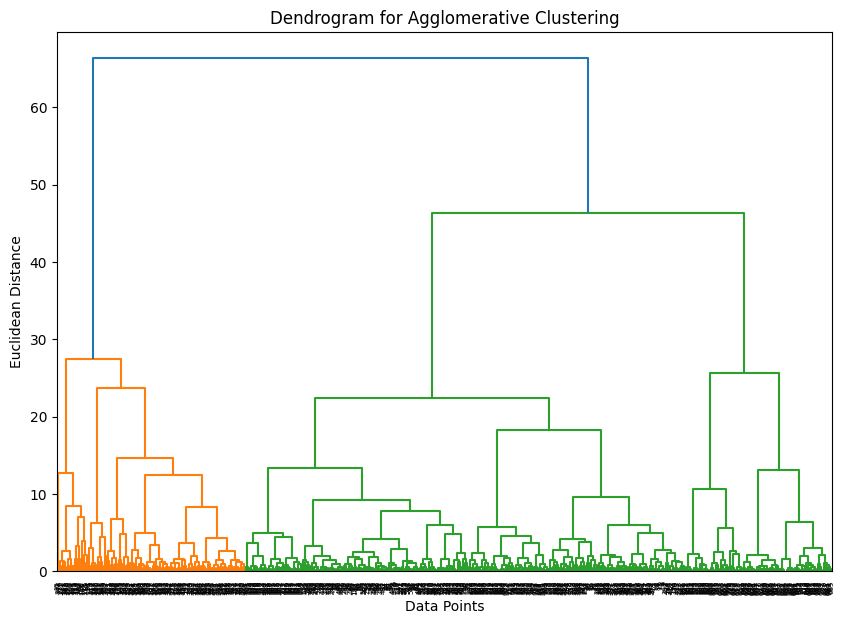

In [171]:
linkage_matrix = linkage(scaled_features, method="ward")

plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram for Agglomerative Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

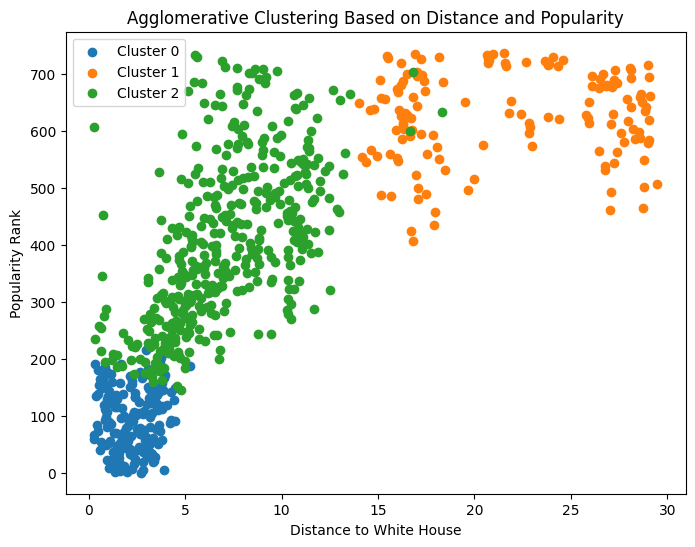

In [172]:
agglo = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
station_sums_with_geo["agglo_cluster"] = agglo.fit_predict(scaled_features)
plt.figure(figsize=(8, 6))
for cluster in range(3):
    cluster_data = station_sums_with_geo[
        station_sums_with_geo["agglo_cluster"] == cluster
    ]
    plt.scatter(
        cluster_data["distance_to_white_house"],
        cluster_data["popularity_rank"],
        label=f"Cluster {cluster}",
    )
plt.xlabel("Distance to White House")
plt.ylabel("Popularity Rank")
plt.title("Agglomerative Clustering Based on Distance and Popularity")
plt.legend()
plt.show()


In [173]:
score = silhouette_score(scaled_features, station_sums_with_geo["agglo_cluster"])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3830


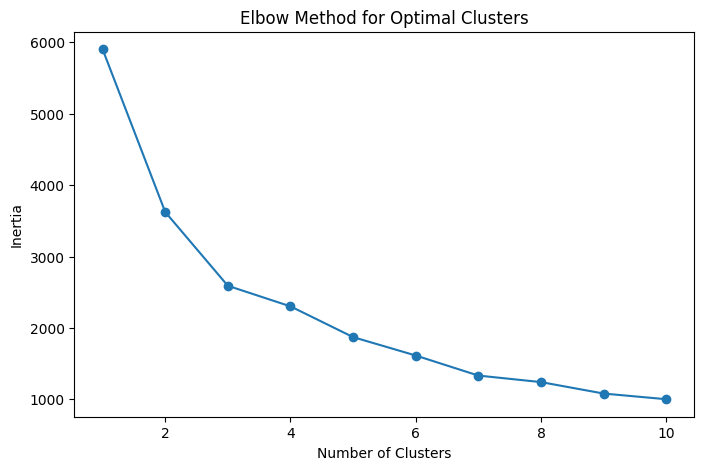

In [174]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

Clusters of stations scattered by distance to center of Washington DC and rank of popularity of the station.


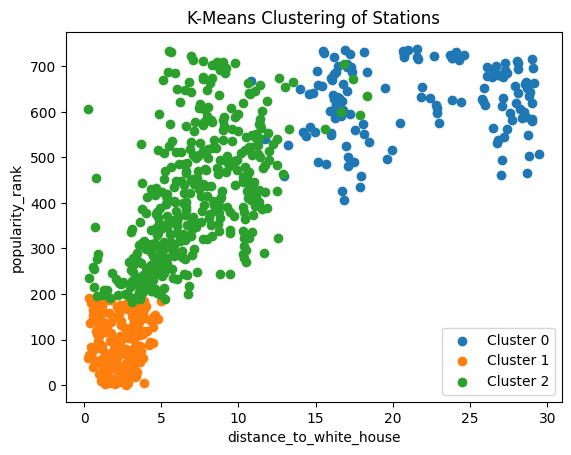

In [175]:
optimal_k = 3  # elbow point
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
station_sums_with_geo["cluster"] = kmeans.fit_predict(scaled_features)
for cluster in range(optimal_k):
    cluster_data = station_sums_with_geo[station_sums_with_geo["cluster"] == cluster]
    plt.scatter(
        cluster_data["distance_to_white_house"],
        cluster_data["popularity_rank"],
        label=f"Cluster {cluster}",
    )
plt.xlabel("distance_to_white_house")
plt.ylabel("popularity_rank")
plt.title("K-Means Clustering of Stations")
plt.legend()
plt.show()

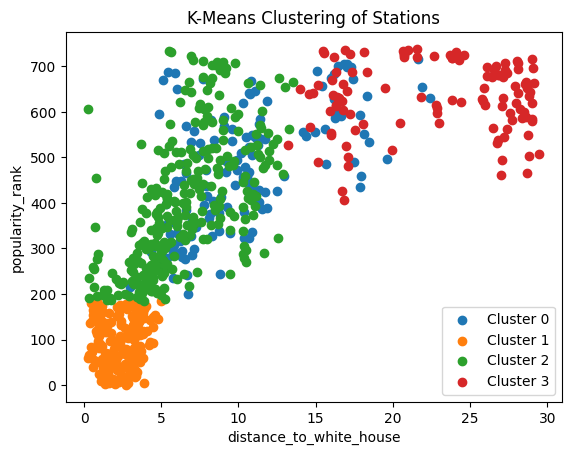

In [176]:
optimal_k = 4  # elbow point
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
station_sums_with_geo["cluster"] = kmeans.fit_predict(scaled_features)
for cluster in range(optimal_k):
    cluster_data = station_sums_with_geo[station_sums_with_geo["cluster"] == cluster]
    plt.scatter(
        cluster_data["distance_to_white_house"],
        cluster_data["popularity_rank"],
        label=f"Cluster {cluster}",
    )
plt.xlabel("distance_to_white_house")
plt.ylabel("popularity_rank")
plt.title("K-Means Clustering of Stations")
plt.legend()
plt.show()

Cluster 3 and 0 overlapped seriously. The performance is not as good as K=3.


### Clusters of Stations scattered by Coordinate


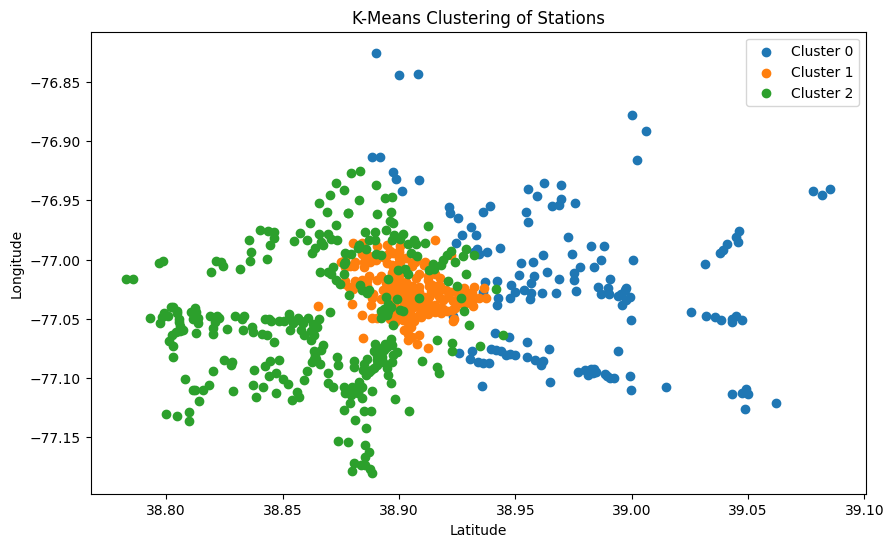

In [177]:
optimal_k = 3
plt.figure(figsize=(10, 6))
for cluster in range(optimal_k):
    cluster_data = station_sums_with_geo[station_sums_with_geo["cluster"] == cluster]
    plt.scatter(
        cluster_data["start_lat"], cluster_data["start_lng"], label=f"Cluster {cluster}"
    )
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("K-Means Clustering of Stations")
plt.legend()
plt.show()

In [178]:
score = silhouette_score(scaled_features, station_sums_with_geo["cluster"])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3033


Silhouette Score of K-means is slightly higher than Agglomerative Clustering (0.3845>0.3850)


In [179]:
station_sums_with_geo.groupby("cluster").mean()

,station_id,start_lat,start_lng,total_pickups,total_dropoffs,utilization_rate,imbalance,popularity_rank,distance_to_white_house,agglo_cluster
cluster,,,,,,,,,,
0,31860.034965,38.973504,-77.020277,1393.615385,1156.986014,2550.601399,236.629371,473.216783,10.310769,1.790210
1,31338.459459,38.903851,-77.026833,15699.837838,15718.956757,31418.794595,-19.118919,93.016216,2.240502,0.118919
2,31550.204698,38.867126,-77.049746,2524.204698,2481.822148,5006.026846,42.382550,393.137584,6.420235,1.966443
3,32135.044643,38.960181,-77.258104,245.214286,209.428571,454.642857,35.785714,630.580357,22.776170,1.008929


**Cluster Interpretation**:

**Cluster 0 (Blue)**:

These stations are geographically further from the White House, as seen in the scatter plot of distance_to_white_house vs. popularity_rank.
These stations are likely located in suburban or less central areas.
They have lower density and are spread over a wider geographical range.

**Cluster 1 (Orange)**:

These stations are very close to the White House and concentrated in the central downtown area, as shown by their small distances and tightly packed distribution.
Likely represents high-demand areas due to proximity to key attractions or business hubs.

**Cluster 2 (Green)**:

These stations are moderately distant from the White House and geographically dispersed.
Represents stations in areas that are somewhat central but not as busy as the downtown core.
These stations likely serve residential neighborhoods or moderately active zones.


## Conclusion

**_Weather's Impact on Bike Usage_**

- Rainy weather significantly reduces bike usage, as observed in Cluster 0 in KMeans and Cluster 2 in Agglomerative. These clusters experience low visibility and high cloud cover, resulting in the lowest ride counts. Electric bike usage is minimal in these conditions, highlighting a preference for better weather.

- In contrast, sunny weather boosts bike demand. Cluster 2 in KMeans and Cluster 1 in Agglomerative demonstrate the highest bike usage, particularly for electric bikes. Favorable conditions such as high solar radiation, minimal cloud cover, and good visibility make these clusters attractive to riders.

- Mixed weather conditions, represented by Cluster 1 in KMeans and Cluster 0 in Agglomerative, support moderate bike usage. These clusters benefit from balanced weather conditions that are neither too severe nor ideal, maintaining steady demand across bike types.

- Seasonal trends align with these patterns. Rainy seasons correspond to lower bike usage, while sunnier months see a significant increase in demand. Electric bikes, in particular, are favored during good weather, supporting longer or more frequent trips.

**Practical Implications**

- Bike Allocation:
Bike-share operators should provide more electric bikes in sunny weather areas where demand tends to be the highest.In rainy weather regions, operators should focus on assigning more classic bikes, as electric bike usage decreases significantly.

- Weather Adjustments:
To encourage bike usage during rainy periods, operators can install covered bike stations or offer promotional discounts to riders.
During sunny weather, operators should prioritize maintenance and improvements at stations to accommodate increased demand.

- Seasonal Planning:
Operators should consider reducing the number of bikes in rainy seasons and redistributing them to locations with higher demand.
During sunnier months, expanding station capacity and increasing the availability of bikes in popular areas can help meet the seasonal surge in demand.

**_Geographical Impact on Bike Demand_**

- Cluster 1 (Orange) has high popularity ranks and proximity to the White House, indicating central stations with likely high utilization.

- Cluster 0 (Blue) has lower popularity ranks and is farther from the White House, suggesting lower utilization and less demand.

- Cluster 2 (Green) has a wide range of popularity ranks, indicating that some stations in this cluster are heavily used, while others are less active.

**Recommendations**:

- Cluster 1 (Orange):
  Focus on maintenance and optimization to handle high demand.
  Consider expanding capacity or adding new stations in nearby areas if demand continues to grow.

- Cluster 0 (Blue):
  Assess these stations for potential underutilization.
  Develop strategies like marketing or optimizing station placement to increase usage in suburban areas.

- Cluster 2 (Green):
  Monitor these stations for emerging trends. Some may grow in importance and shift closer to Cluster 1 characteristics.
  Focus on maintaining current levels of service.
